Mounted at /content/drive
IMPROVED SOLAR POWER GRU FORECASTING MODEL

Configuration:
  - Lookback window: 72 hours of past weather
  - Forecast horizon: 24 hours of future power
  - Maximum epochs: 300
  - Batch size: 32

STEP 1: LOADING AND PREPARING DATA

  Loaded 43302 rows from CSV
  ✓ Added 6 cyclic time features

  Features used (10):
    Weather: ['temperature', 'humidity', 'solar_radiation', 'pressure']
    Time: ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']

  Data shapes:
    - Input sequences: (43206, 72, 10)
      → (num_samples, lookback_hours, num_features)
    - Output sequences: (43206, 24)
      → (num_samples, forecast_hours)

Data splits (temporal):
  - Training: 30244 samples
  - Validation: 6481 samples
  - Test: 6481 samples

STEP 2: BUILDING MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 72, 128)        │        53,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 72, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,704 (405.09 KB)

 Trainable params: 103,064 (402.59 KB)

 Non-trainable params: 640 (2.50 KB)

None

STEP 3: TRAINING MODEL
Epoch 1/300
946/946 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2386 - mae: 0.4240 - mse: 0.3830
Epoch 1: val_loss improved from inf to 0.01787, saving model to best_improved_gru_model.keras
946/946 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - loss: 0.2385 - mae: 0.4238 - mse: 0.3827 - val_loss: 0.0179 - val_mae: 0.0679 - val_mse: 0.0080 - learning_rate: 0.0010
Epoch 2/300
943/946 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0139 - mae: 0.0779 - mse: 0.0113
Epoch 2: val_loss improved from 0.01787 to 0.00472, saving model to best_improved_gru_model.keras
946/946 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - loss: 0.0138 - mae: 0.0779 - mse: 0.0113 - val_loss: 0.0047 - val_mae: 0.0623 - val_mse: 0.0072 - learning_rate: 0.0010
Epoch 3/300
945/946 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0062 - mae: 0.0750 - mse: 0.0107
Epoch 3: val_loss improved from 0.00472 to 0.00357, saving model to best_improved_gru_model.keras
946/946 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - loss: 0.0062 - 

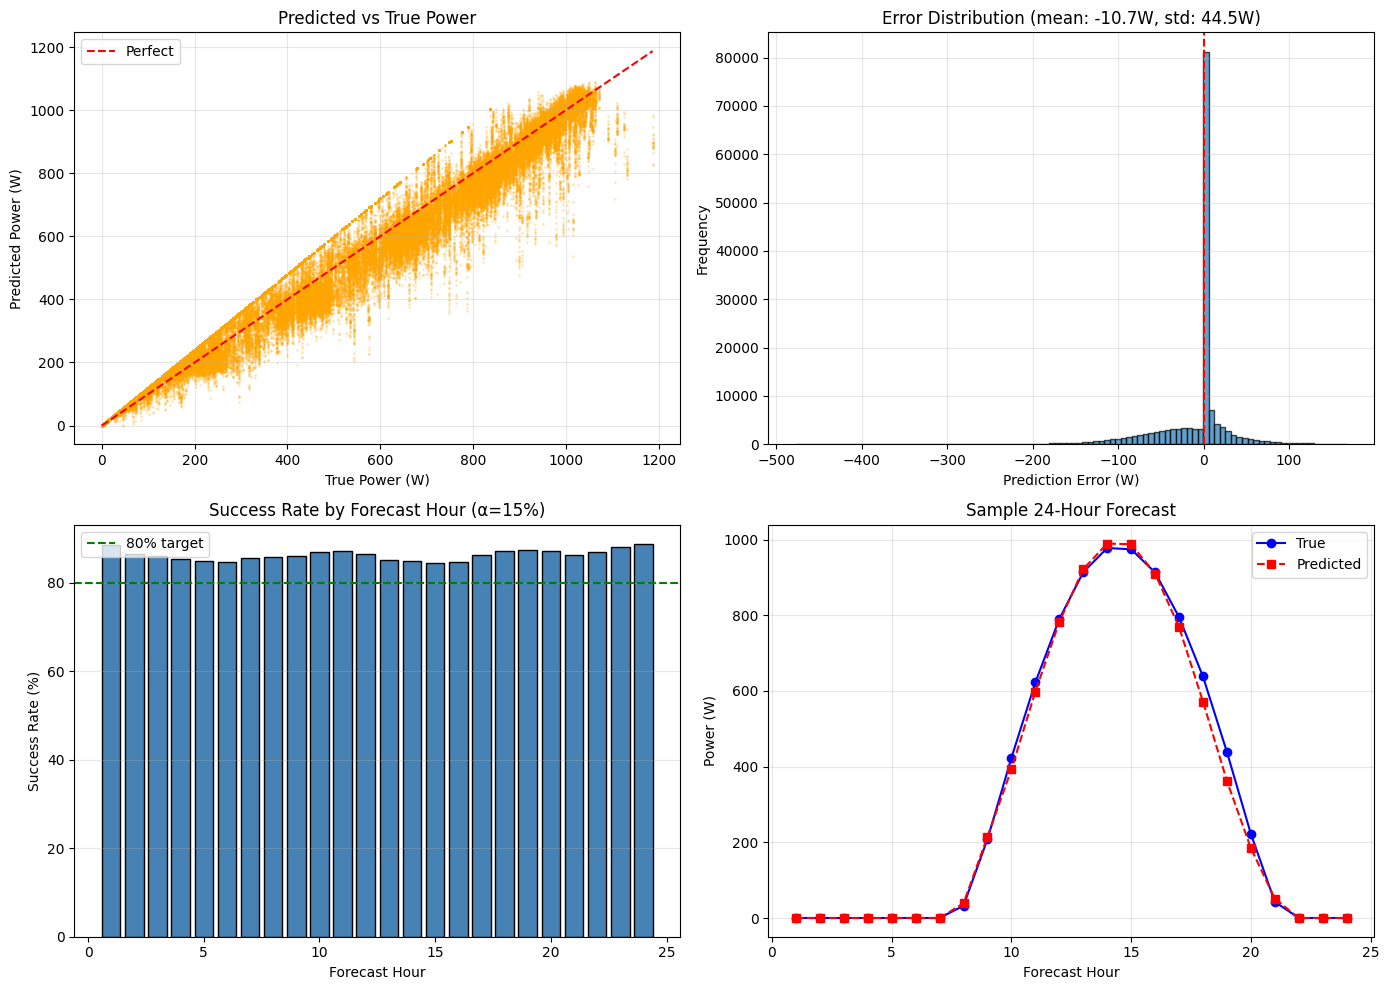


✓ Results plot saved to 'model_results.png'

✓ Model saved to 'solar_gru_model.keras'

✓ weather scaler saved to 'gru_weather_scaler.pkl'

✓ power scaler saved to 'gru_power_scaler.pkl'


✓ Evaluation results saved to: /content/drive/MyDrive/models/gru/5Y_chosen_with_pressure/model_evaluation_results.csv


✓ Additional Metrics saved to: /content/drive/MyDrive/models/gru/5Y_chosen_with_pressure/model_evaluation_additional_metrics.csv


In [ ]:
import tensorflow as tf
import keras
from keras import layers, regularizers
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
from google.colab import drive
import pickle
import os

# Mount Google Drive
drive.mount('/content/drive')
DIR_OUT = '/content/drive/MyDrive/models/gru/5Y_chosen_with_pressure'
os.makedirs(DIR_OUT, exist_ok=True)

# ============================================================================
# CONFIGURATION
# ============================================================================
LOOKBACK_HOURS = 72
FORECAST_HOURS = 24
MAX_EPOCHS = 300
BATCH_SIZE = 32
CSV_PATH = "/content/drive/MyDrive/models/inputs/weather_data_with_labels_5_years_with_pressure.csv"

print("=" * 70)
print("IMPROVED SOLAR POWER GRU FORECASTING MODEL")
print("=" * 70)
print(f"\nConfiguration:")
print(f"  - Lookback window: {LOOKBACK_HOURS} hours of past weather")
print(f"  - Forecast horizon: {FORECAST_HOURS} hours of future power")
print(f"  - Maximum epochs: {MAX_EPOCHS}")
print(f"  - Batch size: {BATCH_SIZE}")


# ============================================================================
# ADD CYCLIC TIME FEATURES
# ============================================================================
def add_cyclic_time_features(df):
    """
    Add cyclic time features using sin/cos encoding.

    The sin/cos encoding preserves the cyclic nature:
    - Hour 23 should be close to hour 0 (midnight wraps around)
    - December should be close to January
    """
    # Ensure datetime column exists
    if 'date_time' not in df.columns:
        # Try to find or create datetime
        if 'date' in df.columns and 'time' in df.columns:
            df['date_time'] = pd.to_datetime(df['date'] + ' ' + df['time'])
        elif 'timestamp' in df.columns:
            df['date_time'] = pd.to_datetime(df['timestamp'])
        else:
            # Assume index is datetime or create from index
            try:
                df['date_time'] = pd.to_datetime(df.index)
            except:
                raise ValueError("Could not find or create datetime column")

    df['date_time'] = pd.to_datetime(df['date_time'])

    # Extract time components
    hour = df['date_time'].dt.hour
    day_of_year = df['date_time'].dt.dayofyear
    month = df['date_time'].dt.month

    # Cyclic encoding using sin/cos
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24)

    df['day_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df['day_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)

    df['month_sin'] = np.sin(2 * np.pi * month / 12)
    df['month_cos'] = np.cos(2 * np.pi * month / 12)

    print(f"  ✓ Added 6 cyclic time features")
    return df


# ============================================================================
# LOAD AND PREPARE DATA
# ============================================================================
def load_and_prepare_data(csv_path, lookback_hours, forecast_hours):
    """
    Load data and prepare sequences.
    """
    print("\n" + "=" * 70)
    print("STEP 1: LOADING AND PREPARING DATA")
    print("=" * 70)

    dataframe = pd.read_csv(csv_path)
    print(f"\n  Loaded {len(dataframe)} rows from CSV")

    # Add cyclic time features
    dataframe = add_cyclic_time_features(dataframe)

    core_weather = ['temperature', 'humidity', 'solar_radiation', 'pressure']
    time_features = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']
    weather_columns = core_weather + time_features

    power_column = 'pv_output'

    print(f"\n  Features used ({len(weather_columns)}):")
    print(f"    Weather: {core_weather}")
    print(f"    Time: {time_features}")

    # Extract data
    weather_data = dataframe[weather_columns].values
    power_data = dataframe[power_column].values

    # Normalize the data
    weather_scaler = StandardScaler()
    power_scaler = MinMaxScaler()

    weather_normalized = weather_scaler.fit_transform(weather_data)
    power_normalized = power_scaler.fit_transform(power_data.reshape(-1, 1)).flatten()

    # Create sequences
    sequences_input = []
    sequences_output = []

    for i in range(len(dataframe) - lookback_hours - forecast_hours):
        input_weather = weather_normalized[i:i + lookback_hours]
        sequences_input.append(input_weather)

        output_power = power_normalized[i + lookback_hours:i + lookback_hours + forecast_hours]
        sequences_output.append(output_power)

    sequences_input = np.array(sequences_input)
    sequences_output = np.array(sequences_output)

    print(f"\n  Data shapes:")
    print(f"    - Input sequences: {sequences_input.shape}")
    print(f"      → (num_samples, lookback_hours, num_features)")
    print(f"    - Output sequences: {sequences_output.shape}")
    print(f"      → (num_samples, forecast_hours)")

    return sequences_input, sequences_output, weather_scaler, power_scaler, dataframe


# ============================================================================
# BUILD GRU MODEL
# ============================================================================
def build_gru_model(lookback_hours, num_features, forecast_hours):
    """
    Build GRU model.
    """
    print("\n" + "=" * 70)
    print("STEP 2: BUILDING MODEL")
    print("=" * 70)

    model = keras.Sequential([
        keras.Input(shape=(lookback_hours, num_features)),

        # First GRU layer
        layers.GRU(128,
                   return_sequences=True,
                   kernel_regularizer=regularizers.l2(0.0005),
                   recurrent_regularizer=regularizers.l2(0.0005)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Second GRU layer
        layers.GRU(64,
                   return_sequences=False,
                   kernel_regularizer=regularizers.l2(0.0005),
                   recurrent_regularizer=regularizers.l2(0.0005)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Dense layer
        layers.Dense(128,
                     activation='relu',
                     kernel_regularizer=regularizers.l2(0.0005)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Output layer: LINEAR activation (result will be clipped [0, 1] after prediction)
        layers.Dense(forecast_hours, activation='linear')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=keras.losses.Huber(delta=0.5),
        metrics=['mae', 'mse']
    )

    print(model.summary())
    return model


# ============================================================================
# TRAIN MODEL
# ============================================================================
def train_model(model, train_input, train_output, val_input, val_output,
                num_epochs=300, batch_size=32):
    """Train the GRU model with callbacks"""
    print("\n" + "=" * 70)
    print("STEP 3: TRAINING MODEL")
    print("=" * 70)

    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=50,
        restore_best_weights=True,
        min_delta=0.0001,
        verbose=1
    )

    reduce_learning_rate = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.7,
        patience=15,
        min_lr=0.00001,
        verbose=1,
        cooldown=5
    )

    checkpoint = keras.callbacks.ModelCheckpoint(
        'best_improved_gru_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    training_history = model.fit(
        train_input, train_output,
        validation_data=(val_input, val_output),
        epochs=num_epochs,
        batch_size=batch_size,
        callbacks=[early_stopping, reduce_learning_rate, checkpoint],
        verbose=1
    )

    return training_history


# ============================================================================
# EVALUATION FUNCTIONS
# ============================================================================
def evaluate_predictions(y_true, y_pred, alpha=0.1):
    """
    Evaluate predictions using success rate metric.

    Success criteria: abs(pred - true) < (pred + true) * alpha / 2
    With minimum threshold of 20W
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    threshold = (y_pred + y_true) * alpha / 2
    threshold = np.maximum(threshold, 20)  # Minimum 20W threshold

    errors = np.abs(y_pred - y_true)
    successful_mask = errors < threshold
    incorrect_mask = ~successful_mask

    success_rate = np.mean(successful_mask) * 100

    if np.any(incorrect_mask):
        conditional_mae = np.mean(errors[incorrect_mask])
    else:
        conditional_mae = 0.0

    return success_rate, conditional_mae


def evaluate_model_comprehensive(model, test_input, test_output, power_scaler):
    """
    Comprehensive model evaluation with all metrics.
    """
    print("\n" + "=" * 70)
    print("STEP 4: EVALUATING MODEL PERFORMANCE")
    print("=" * 70)

    alphas = [0.05, 0.10, 0.15, 0.2]

    # Get predictions
    predictions_normalized = model.predict(test_input)

    # Clip predictions to [0, 1] range (since we use linear activation)
    predictions_normalized = np.clip(predictions_normalized, 0, 1)

    # Convert back to original scale
    y_pred = power_scaler.inverse_transform(predictions_normalized.reshape(-1, 1)).flatten()
    y_true = power_scaler.inverse_transform(test_output.reshape(-1, 1)).flatten()

    y_pred = np.clip(y_pred, 0, y_true * 1.2)  # hard limit at the maximum possible output + 20%

    # Reshape for per-hour analysis
    y_pred_reshaped = y_pred.reshape(-1, FORECAST_HOURS)
    y_true_reshaped = y_true.reshape(-1, FORECAST_HOURS)

    # Overall evaluation
    print("\n" + "=" * 70)
    print("OVERALL TEST SET PERFORMANCE")
    print("=" * 70)

    results_data = []
    for alpha in alphas:
        success_rate, conditional_mae = evaluate_predictions(y_true, y_pred, alpha)
        print(f"\nAlpha = {alpha*100:.1f}% (±{alpha*100:.1f}% error tolerance):")
        print(f"  - Success Rate: {success_rate:.2f}%")
        print(f"  - Conditional MAE: {conditional_mae:.4f}")

        # Add to results data
        results_data.append({
            'Alpha': alpha,
            'Success_Rate_%': success_rate,
            'Conditional_MAE': conditional_mae
        })

    results_df = pd.DataFrame(results_data)
    results_df = results_df.sort_values(['Alpha']).reset_index(drop=True)

    # Additional metrics
    print("\n" + "=" * 70)
    print("ADDITIONAL METRICS")
    print("=" * 70)

    # Overall metrics
    mae = np.mean(np.abs(y_pred - y_true))
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

    # Daytime MAPE (avoid division by zero)
    daytime_mask = y_true > 15
    y_true_day = y_true[daytime_mask]
    y_pred_day = y_pred[daytime_mask]
    mape_day = np.mean(np.abs((y_true_day - y_pred_day) / y_true_day)) * 100

    print(f"\nOverall MAE: {mae:.2f} W")
    print(f"Overall RMSE: {rmse:.2f} W")
    print(f"Daytime MAPE: {mape_day:.2f}%")

    additional_metrics = {
        'MAE': mae,
        'RMSE': rmse,
        'Daytime_MAPE': mape_day
    }
    additional_metrics_df = pd.DataFrame(list(additional_metrics.items()),
                                      columns=['Metric', 'Value'])

    return {
        'y_true': y_true,
        'y_pred': y_pred,
        'y_true_reshaped': y_true_reshaped,
        'y_pred_reshaped': y_pred_reshaped,
        'results_df': results_df,
        'additional_metrics_df': additional_metrics_df
    }


def plot_results(results):
    """Create visualization plots"""
    y_true = results['y_true']
    y_pred = results['y_pred']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Scatter plot
    ax1 = axes[0, 0]
    ax1.scatter(y_true, y_pred, alpha=0.2, s=1, c='orange')
    ax1.plot([0, y_true.max()], [0, y_true.max()], 'r--', label='Perfect')
    ax1.set_xlabel('True Power (W)')
    ax1.set_ylabel('Predicted Power (W)')
    ax1.set_title('Predicted vs True Power')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Error distribution
    ax2 = axes[0, 1]
    errors = y_pred - y_true
    ax2.hist(errors, bins=100, edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='r', linestyle='--')
    ax2.set_xlabel('Prediction Error (W)')
    ax2.set_ylabel('Frequency')
    ax2.set_title(f'Error Distribution (mean: {np.mean(errors):.1f}W, std: {np.std(errors):.1f}W)')
    ax2.grid(True, alpha=0.3)

    # 3. Per-hour success rate
    ax3 = axes[1, 0]
    y_true_reshaped = results['y_true_reshaped']
    y_pred_reshaped = results['y_pred_reshaped']

    hourly_success = []
    for h in range(FORECAST_HOURS):
        sr, _ = evaluate_predictions(y_true_reshaped[:, h], y_pred_reshaped[:, h], alpha=0.15)
        hourly_success.append(sr)

    ax3.bar(range(1, FORECAST_HOURS+1), hourly_success, color='steelblue', edgecolor='black')
    ax3.axhline(y=80, color='g', linestyle='--', label='80% target')
    ax3.set_xlabel('Forecast Hour')
    ax3.set_ylabel('Success Rate (%)')
    ax3.set_title('Success Rate by Forecast Hour (α=15%)')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Sample prediction
    ax4 = axes[1, 1]
    sample_idx = len(y_true_reshaped) // 2  # Middle sample
    ax4.plot(range(1, FORECAST_HOURS+1), y_true_reshaped[sample_idx], 'b-o', label='True')
    ax4.plot(range(1, FORECAST_HOURS+1), y_pred_reshaped[sample_idx], 'r--s', label='Predicted')
    ax4.set_xlabel('Forecast Hour')
    ax4.set_ylabel('Power (W)')
    ax4.set_title('Sample 24-Hour Forecast')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(DIR_OUT + '/model_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Results plot saved to 'model_results.png'")


# ============================================================================
# MAIN EXECUTION
# ============================================================================
def main():
    """Main execution function"""

    # Load and prepare data
    sequences_input, sequences_output, weather_scaler, power_scaler, dataframe = \
        load_and_prepare_data(CSV_PATH, LOOKBACK_HOURS, FORECAST_HOURS)

    # Split data temporally
    n_samples = len(sequences_input)
    train_end = int(n_samples * 0.7)
    val_end = int(n_samples * 0.85)

    train_input = sequences_input[:train_end]
    train_output = sequences_output[:train_end]
    val_input = sequences_input[train_end:val_end]
    val_output = sequences_output[train_end:val_end]
    test_input = sequences_input[val_end:]
    test_output = sequences_output[val_end:]

    print(f"\nData splits (temporal):")
    print(f"  - Training: {len(train_input)} samples")
    print(f"  - Validation: {len(val_input)} samples")
    print(f"  - Test: {len(test_input)} samples")

    # Build model
    num_features = sequences_input.shape[2]
    model = build_gru_model(LOOKBACK_HOURS, num_features, FORECAST_HOURS)

    # Train model
    history = train_model(model, train_input, train_output, val_input, val_output,
                         num_epochs=MAX_EPOCHS, batch_size=BATCH_SIZE)

    # Evaluate model
    results = evaluate_model_comprehensive(model, test_input, test_output, power_scaler)

    # Plot results
    plot_results(results)

    # Save model
    model.save(DIR_OUT + '/solar_gru_model.keras')
    print("\n✓ Model saved to 'solar_gru_model.keras'")

    pickle.dump(weather_scaler, open(DIR_OUT + '/gru_weather_scaler.pkl', 'wb'))
    print("\n✓ weather scaler saved to 'gru_weather_scaler.pkl'")

    pickle.dump(power_scaler, open(DIR_OUT + '/gru_power_scaler.pkl', 'wb'))
    print("\n✓ power scaler saved to 'gru_power_scaler.pkl'")


    results_csv_filename = DIR_OUT + '/model_evaluation_results.csv'
    results["results_df"].to_csv(results_csv_filename, index=False)
    print(f"\n\n✓ Evaluation results saved to: {results_csv_filename}")

    additional_metrics_csv_filename = DIR_OUT + '/model_evaluation_additional_metrics.csv'
    results["additional_metrics_df"].to_csv(additional_metrics_csv_filename, index=False)
    print(f"\n\n✓ Additional Metrics saved to: {additional_metrics_csv_filename}")

    return model, results, history


# Run the main function
if __name__ == "__main__":
    model, results, history = main()
